# Import Libraries and read file

In [17]:
import pandas as pd
import os

low_x0, low_y0, low_w, low_h, bottom_z, top_z = -500, -500, 1000, 1000, -500, 500

def get_velz_dens(x_range, y_range, z_range):
    # read a 3D grid of velz and density array
    velz = obj["flash", "velz"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value        
    dens = obj["flash", "dens"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('g/cm**3').value        
    temp = obj["flash", "temp"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('K').value 

    print(f"obj.shape: {obj['flash', 'velz'].shape}")
    print("x, y, z ranges: ", x_range, y_range, z_range)
    print(f"velz.shape: {velz.shape}\tdens.shape: {dens.shape}\n\n")      
     

    dz = obj['flash', 'dz'][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('cm').value
    mp = yt.physical_constants.mp.value # proton mass

    # calculate the density as column density
    coldens = dens * dz / (1.4 * mp)

    return velz, coldens, temp

def get_velx_vely(x_range, y_range, z_range):
    # read a 3D grid of vely and density array
    vely = obj["flash", "vely"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value
    velx = obj["flash", "velx"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value
    
    print(f"velx.shape: {velx.shape}\tvely.shape: {vely.shape}\n\n")      
    
    return velx, vely

# convert seconds to Megayears
def seconds_to_megayears(seconds):
    return seconds / (1e6 * 365 * 24 * 3600)

def pc2pixel(coord, x_y_z):
    if x_y_z == "x":
        return coord + top_z
    elif x_y_z == "y":
        return top_z - coord
    elif x_y_z == "z":
        return coord + top_z
    return coord

def pixel2pc(coord, x_y_z):
    if x_y_z == "x":
        return coord - top_z
    elif x_y_z == "y":
        return top_z - coord
    elif x_y_z == "z":
        return coord - top_z
    return coord

def cm2pc(cm):
    return cm * 3.24077929e-19

# filter the DataFrame
def filter_data(df, range_coord):
    return df[(df['posx_pc'] > range_coord[0]) & (df['posx_pc'] < range_coord[0] + range_coord[2]) & (df['posy_pc'] > range_coord[1]) & (df['posy_pc'] < range_coord[1] + range_coord[3]) & (df['posz_pc'] > range_coord[4] & (df['posz_pc'] < range_coord[5]))]

def timestamp2Myr(timestamp):
    return (timestamp - 200) * 0.1 + 191

def time_Myr2timestamp(time_Myr):
    return round(10 * (time_Myr - 191) + 200)

In [2]:
import matplotlib.pyplot as plt
import astropy
import yt
import numpy as np
import os 
from matplotlib.patches import Rectangle
from matplotlib import cm
import matplotlib.colors as colors

# elephant
hdf5_root = "/srv/data/stratbox_simulations/stratbox_particle_runs/bx5/smd132/sn34/pe300/4pc_resume/4pc"

# s01.leaves
# hdf5_root = "/home/joy0921/Desktop/Dataset/hdf5_files"

# CV lab
# hdf5_root = "/home/joy0921/Desktop/Dataset/hdf5_files"

# Mac
#hdf5_root = "/Users/joycelynchen/Desktop/UBC/Research/Program/Dataset/SB230/HDF5"

time_Myr = 209

ds = yt.load(os.path.join(hdf5_root, 'sn34_smd132_bx5_pe300_hdf5_plt_cnt_0{}'.format(time_Myr2timestamp(time_Myr))))

center = [0, 0, 0] * yt.units.pc
arb_center = ds.arr(center, 'code_length')
xlim = 256
ylim = 256
zlim= 256
left_edge = arb_center + ds.quan(-500, 'pc')
right_edge = arb_center + ds.quan(500, 'pc')
obj = ds.arbitrary_grid(left_edge, right_edge, dims=(256,256,256))

/UBC-O/joy0921/Desktop/Program/AstroSegTrack/.venv/lib/python3.10/site-packages/yt/utilities/logger.py:4: VisibleDeprecationWarning: The configuration file /home/joy0921/.config/yt/ytrc is deprecated in favor of /home/joy0921/.config/yt/yt.toml. Currently, both are present. Please manually remove the deprecated one to silence this warning.
Deprecated since v4.0.0. This feature will be removed in v4.1.0
  from yt.config import ytcfg
yt : [INFO     ] 2024-05-28 18:04:54,478 Particle file found: sn34_smd132_bx5_pe300_hdf5_part_0380
yt : [INFO     ] 2024-05-28 18:04:54,550 Parameters: current_time              = 6595634845883194.0
yt : [INFO     ] 2024-05-28 18:04:54,551 Parameters: domain_dimensions         = [  32   32 1280]
yt : [INFO     ] 2024-05-28 18:04:54,553 Parameters: domain_left_edge          = [-1.54283879e+21 -1.54283879e+21 -6.17135516e+22]
yt : [INFO     ] 2024-05-28 18:04:54,554 Parameters: domain_right_edge         = [1.54283879e+21 1.54283879e+21 6.17135516e+22]
yt : [IN

In [18]:
# retrieve the center (100, 100, 100) grid, zoom in the explosion


# Multiply each element within the tuples by the multiplier
x_range_scaled = (100, 200) #tuple(int(x * multiplier) for x in x_range)
y_range_scaled = (128, 228) #(28, 128) #tuple(int(y * multiplier) for y in y_range)
#z_range_scaled = z_range  
z_range_scaled = (91, 191)
# z_range_scaled = (65, 217) #tuple(int(z * multiplier) for z in z_range)

x, center_y, center_z = pc2pixel(85, x_y_z="x") * 256/1000, int(pc2pixel(196, x_y_z="x") * 256/1000), int(pc2pixel(53, x_y_z="z") * 256/1000)
print(x, center_y, center_z, time_Myr)

center_y = center_y - y_range_scaled[0]
center_z = center_z - z_range_scaled[0]

new_velz, new_dens, new_temp = get_velz_dens(x_range_scaled, y_range_scaled, z_range_scaled)
new_velx, new_vely = get_velx_vely(x_range_scaled, y_range_scaled, z_range_scaled)


149.76 178 141 209
obj.shape: (256, 256, 256)
x, y, z ranges:  (100, 200) (128, 228) (91, 191)
velz.shape: (100, 100, 100)	dens.shape: (100, 100, 100)


velx.shape: (100, 100, 100)	vely.shape: (100, 100, 100)




## X-Y plane velocity

In [173]:
center_z = center_z + 5
center_z

60

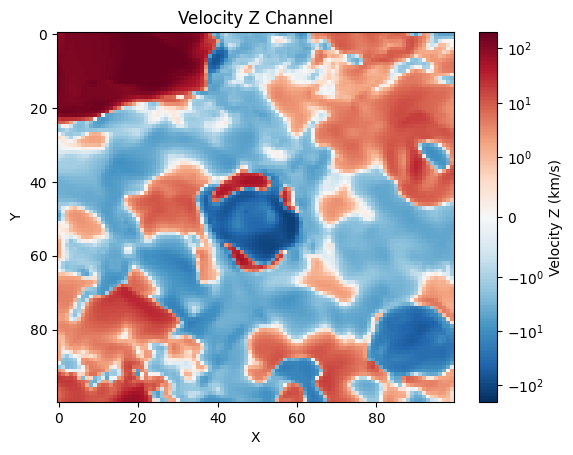

In [20]:
# Velocity slice, log scaled
fig, ax = plt.subplots()
#im = ax.imshow((np.log(new_velz[:, :, center_z].T[::])), cmap='RdBu', aspect='auto')
im = ax.imshow(new_velz[:, :, center_z].T[::], cmap='RdBu_r', aspect='auto',
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
fig.colorbar(im, label='Velocity Z (km/s)')

plt.title('Velocity Z Channel')
plt.xlabel('X')
plt.ylabel('Y')
fig.savefig(f'../expanding_velocity/{time_Myr}/vzoom_velz_cenz_{center_z}.png')
plt.show()

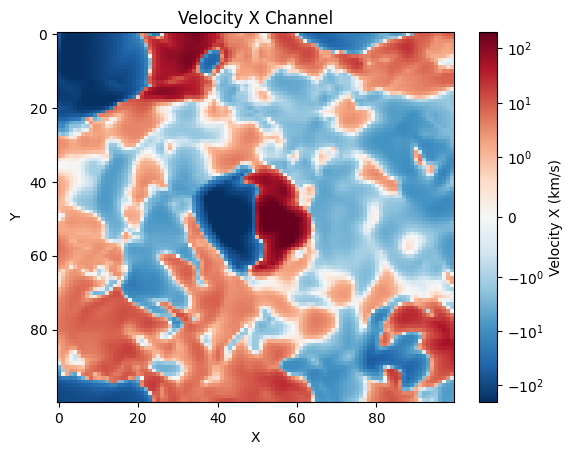

In [19]:
# Velocity slice, log scaled
fig, ax = plt.subplots()
#im = ax.imshow((np.log(new_velz[:, :, center_z].T[::])), cmap='RdBu', aspect='auto')
im = ax.imshow(new_velx[:, :, center_z].T[::], cmap='RdBu_r', aspect='auto',
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
fig.colorbar(im, label='Velocity X (km/s)')

plt.title('Velocity X Channel')
plt.xlabel('X')
plt.ylabel('Y')
fig.savefig(f'../expanding_velocity/{time_Myr}/vzoom_velx_cenz_{center_z}.png')
plt.show()

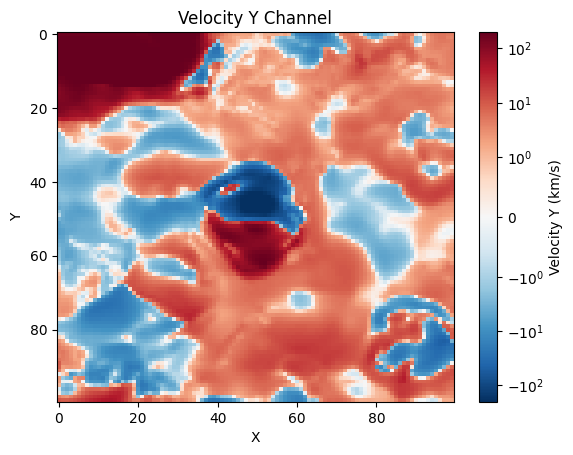

In [21]:
# Velocity slice, log scaled
fig, ax = plt.subplots()
#im = ax.imshow((np.log(new_velz[:, :, center_z].T[::])), cmap='RdBu', aspect='auto')
im = ax.imshow(new_vely[:, :, center_z].T[::], cmap='RdBu_r', aspect='auto',
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
fig.colorbar(im, label='Velocity Y (km/s)')

plt.title('Velocity Y Channel')
plt.xlabel('X')
plt.ylabel('Y')
fig.savefig(f'../expanding_velocity/{time_Myr}/vzoom_vely_cenz_{center_z}.png')
plt.show()

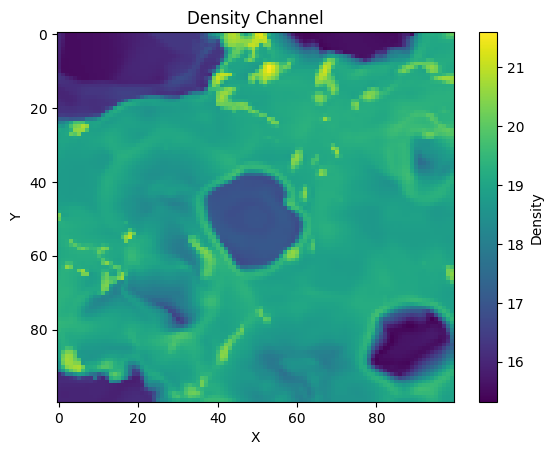

In [211]:
# Density zoom in

fig, ax = plt.subplots()
im = ax.imshow(np.log10(new_dens[:, :, center_z].T[::]), cmap='viridis', aspect='auto')
fig.colorbar(im, label='Density')
plt.title('Density Channel')
plt.xlabel('X')
plt.ylabel('Y')
fig.savefig(f'../expanding_velocity/{time_Myr}/dzoom_{center_z}.png')
plt.show()


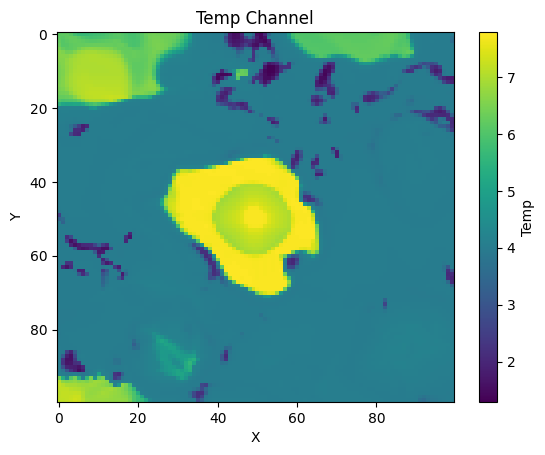

In [208]:
# Density zoom in

fig, ax = plt.subplots()
im = ax.imshow(np.log10(new_temp[:, :, center_z].T[::]), cmap='viridis', aspect='auto')
fig.colorbar(im, label='Temp')


## Mass Flux 
- x-y plane

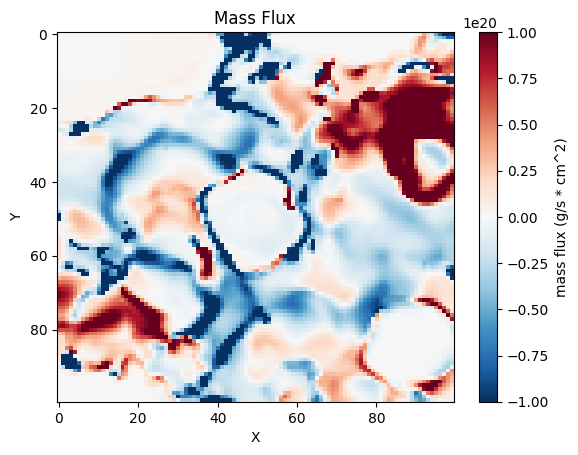

In [13]:
# velz * dens -> mass flux
import yt.config


fig, ax = plt.subplots()
#im = ax.imshow((np.log(new_velz[:, :, center_z].T[::])), cmap='RdBu', aspect='auto')
mass_flux = new_velz * new_dens
im = ax.imshow((mass_flux[:, :, center_z].T[::]), cmap='RdBu_r', aspect='auto',
               vmin=-1e20, vmax=1e20)#
                #norm=colors.SymLogNorm(linthresh=1))#, vmin=-200, vmax=200))
fig.colorbar(im, label='mass flux (g/s * cm^2)')

plt.title('Mass Flux')
plt.xlabel('X')
plt.ylabel('Y')
fig.savefig(f'../expanding_velocity/{time_Myr}/mass_flux_cenz_{center_z}.png')
plt.show()

## X-Z plane velocity-dens pairs

In [6]:
# center_y = center_y - 20
center_y = center_y - 5
center_y

45

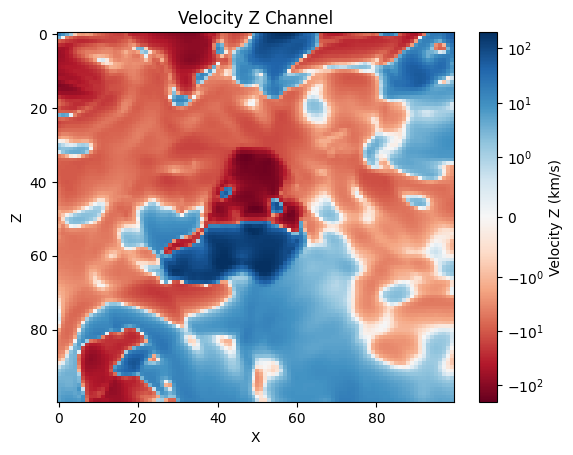

In [22]:
# Velocity slice, log scaled
fig, ax = plt.subplots()
#im = ax.imshow((np.log(new_velz[:, :, center_z].T[::])), cmap='RdBu', aspect='auto')
im = ax.imshow(new_velz[:, center_y, :].T[::], cmap='RdBu', aspect='auto',# vmin=-200, vmax=200)
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
fig.colorbar(im, label='Velocity Z (km/s)')

plt.title('Velocity Z Channel')
plt.xlabel('X')
plt.ylabel('Z')
fig.savefig(f'../expanding_velocity/{time_Myr}/vzoom_velz_ceny_{center_y}.png')
plt.show()

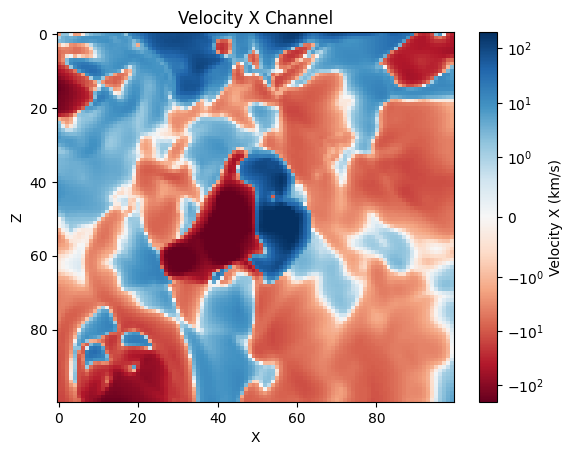

In [23]:
# Velocity slice, log scaled
fig, ax = plt.subplots()
im = ax.imshow(new_velx[:, center_y, :].T[::], cmap='RdBu', aspect='auto',# vmin=-200, vmax=200)
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
fig.colorbar(im, label='Velocity X (km/s)')

plt.title('Velocity X Channel')
plt.xlabel('X')
plt.ylabel('Z')
fig.savefig(f'../expanding_velocity/{time_Myr}/vzoom_velx_ceny_{center_y}.png')
plt.show()

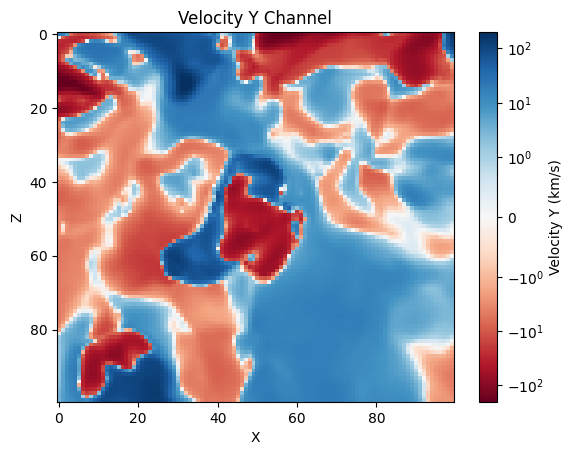

In [24]:
# Velocity slice, log scaled
fig, ax = plt.subplots()
im = ax.imshow(new_vely[:, center_y, :].T[::], cmap='RdBu', aspect='auto',# vmin=-200, vmax=200)
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
fig.colorbar(im, label='Velocity Y (km/s)')

plt.title('Velocity Y Channel')
plt.xlabel('X')
plt.ylabel('Z')
fig.savefig(f'../expanding_velocity/{time_Myr}/vzoom_vely_ceny_{center_y}.png')
plt.show()

## Mass flux 
- x-z plane

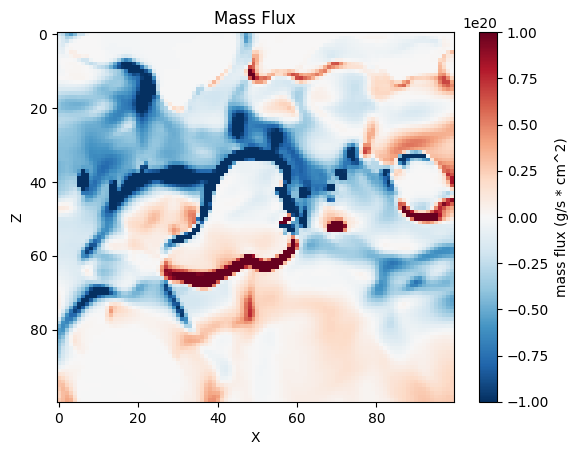

In [14]:
# velz * dens -> mass flux
import yt.config


fig, ax = plt.subplots()
#im = ax.imshow((np.log(new_velz[:, :, center_z].T[::])), cmap='RdBu', aspect='auto')
mass_flux = new_velz * new_dens
im = ax.imshow((mass_flux[:, center_y,:].T[::]), cmap='RdBu_r', aspect='auto',
               vmin=-1e20, vmax=1e20)#
                #norm=colors.SymLogNorm(linthresh=1))#, vmin=-200, vmax=200))
fig.colorbar(im, label='mass flux (g/s * cm^2)')

plt.title('Mass Flux')
plt.xlabel('X')
plt.ylabel('Z')
fig.savefig(f'../expanding_velocity/{time_Myr}/mass_flux_ceny_{center_y}.png')
plt.show()

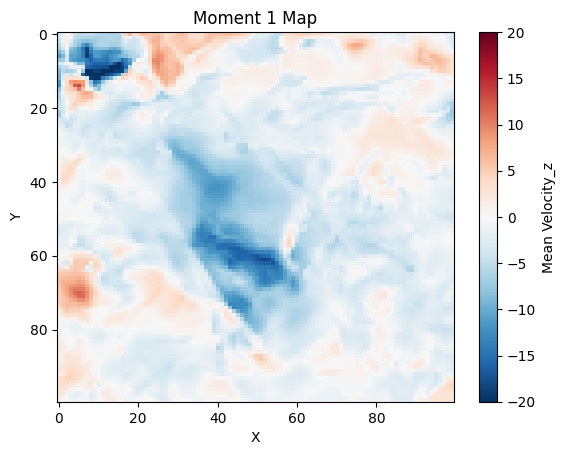

In [ ]:
# Moment 1 map
moment_1 = np.sum(new_velz * new_dens, axis=-1) / np.sum(new_dens, axis=-1)
moment_1.shape

fig, ax = plt.subplots()
im = ax.imshow((moment_1.T[::]), cmap='RdBu_r', aspect='auto', vmin=-20,vmax=20)
fig.colorbar(im, label='Mean Velocity_z')
plt.title('Moment 1 Map')
plt.xlabel('X')
plt.ylabel('Y')
fig.savefig(f'channel_maps/SBid_230/{time_Myr}/moment_1_vz.png')
plt.show()